este analisis es mas que nada por diversion.
segun claude estos datos:
datos reales, pero de una encuesta, no observación directa ni experimento controlado — así que hay que tomarlos con cierto cuidado.
El dataset original viene del estudio de Ray Fair (1978), un economista que quería modelar economically los determinantes del "affair". Él combinó datos de dos encuestas:

Una encuesta de la revista Psychology Today de 1969, sobre sexualidad.
Una encuesta de la revista Redbook de 1974, con una muestra más grande y mejor diseñada.

O sea, son autoreportes de personas reales que respondieron cuestionarios de revistas — no es un registro objetivo ni verificado de comportamiento. Esto trae varios sesgos importantes que vale la pena tener en cuenta si lo usas para modelar:

Sesgo de selección: quienes responden encuestas de revista sobre sexualidad no son necesariamente representativos de la población general.
Sesgo de deseabilidad social: la gente puede subreportar (o en algunos casos exagerar) infidelidad.
Antigüedad: los datos son de finales de los 60s/70s — normas sociales sobre matrimonio, género y relaciones han cambiado bastante desde entonces.
Definición ambigua de "affair": depende de cómo cada persona interpretó la pregunta (¿un beso cuenta? ¿solo relaciones sexuales?).

VariableQué esNotasrate_marriageAutoevaluación de qué tan buena es su relación matrimonial (escala 1 = muy mala, 5 = muy buena)Variable subjetiva, probablemente tu predictor más fuerteageEdad de la personaContinuayrs_marriedAños de casada/oNota que tiene valores como 2.5 o 16.5 — están en bins también (no son reportes exactos, sino rangos convertidos a punto medio)childrenNúmero de hijosTambién aparece con decimales (0.5, etc.) en algunas versiones — mismo fenómeno de binsreligiousQué tan religiosa se considera (1 = nada, 4 = muy religiosa)Escala LikerteducAños de educación formalEj. 12 = high school, 16 = licenciatura, 17 = posgrado empezadooccupationCategoría ocupacional de la persona (escala 1-6, tipo Hollingshead)Codificada, no es texto libreoccupation_husbCategoría ocupacional del esposoMismo esquema
Detalle importante para tu EDA/feature engineering: varias de estas variables

para esto asumiremos que 0 es no hubo infidelidad

In [62]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as sms
from scipy import stats

#modelos usados
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

#entrenamiento del modelo

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

#ajuste de hiperparametros

import optuna

#evaluacion del modelo

from sklearn.metrics import confusion_matrix, classification_report,f1_score,accuracy_score,recall_score

#comparacion 

from sklearn.dummy import DummyClassifier

#interpretacion 

import shap

#guardar modelos

from joblib import dump

# VISTA RAPIDA DEL DF

In [63]:
df = sm.datasets.fair.load_pandas().data
df

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666
...,...,...,...,...,...,...,...,...,...
6361,5.0,32.0,13.0,2.0,3.0,17.0,4.0,3.0,0.000000
6362,4.0,32.0,13.0,1.0,1.0,16.0,5.0,5.0,0.000000
6363,5.0,22.0,2.5,0.0,2.0,14.0,3.0,1.0,0.000000
6364,5.0,32.0,6.0,1.0,3.0,14.0,3.0,4.0,0.000000


creamos una nueva variable binaria, fue infiel o no

In [64]:
df['affair'] = (df['affairs']>0).astype(int)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6366 entries, 0 to 6365
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rate_marriage    6366 non-null   float64
 1   age              6366 non-null   float64
 2   yrs_married      6366 non-null   float64
 3   children         6366 non-null   float64
 4   religious        6366 non-null   float64
 5   educ             6366 non-null   float64
 6   occupation       6366 non-null   float64
 7   occupation_husb  6366 non-null   float64
 8   affairs          6366 non-null   float64
 9   affair           6366 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 497.5 KB


In [66]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rate_marriage,6366.0,4.109645,0.961430,1.0,4.0,4.0,5.000000,5.000000
age,6366.0,29.082862,6.847882,17.5,22.0,27.0,32.000000,42.000000
yrs_married,6366.0,9.009425,7.280120,0.5,2.5,6.0,16.500000,23.000000
children,6366.0,1.396874,1.433471,0.0,0.0,1.0,2.000000,5.500000
religious,6366.0,2.426170,0.878369,1.0,2.0,2.0,3.000000,4.000000
educ,6366.0,14.209865,2.178003,9.0,12.0,14.0,16.000000,20.000000
occupation,6366.0,3.424128,0.942399,1.0,3.0,3.0,4.000000,6.000000
occupation_husb,6366.0,3.850141,1.346435,1.0,3.0,4.0,5.000000,6.000000
affairs,6366.0,0.705374,2.203374,0.0,0.0,0.0,0.484848,57.599991
affair,6366.0,0.322495,0.467468,0.0,0.0,0.0,1.000000,1.000000


# NULOS

revisamos nulos por si las dudas

c:\Users\Diego\AppData\Local\Programs\Python\Python313\Lib\site-packages\missingno\missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


<Axes: >

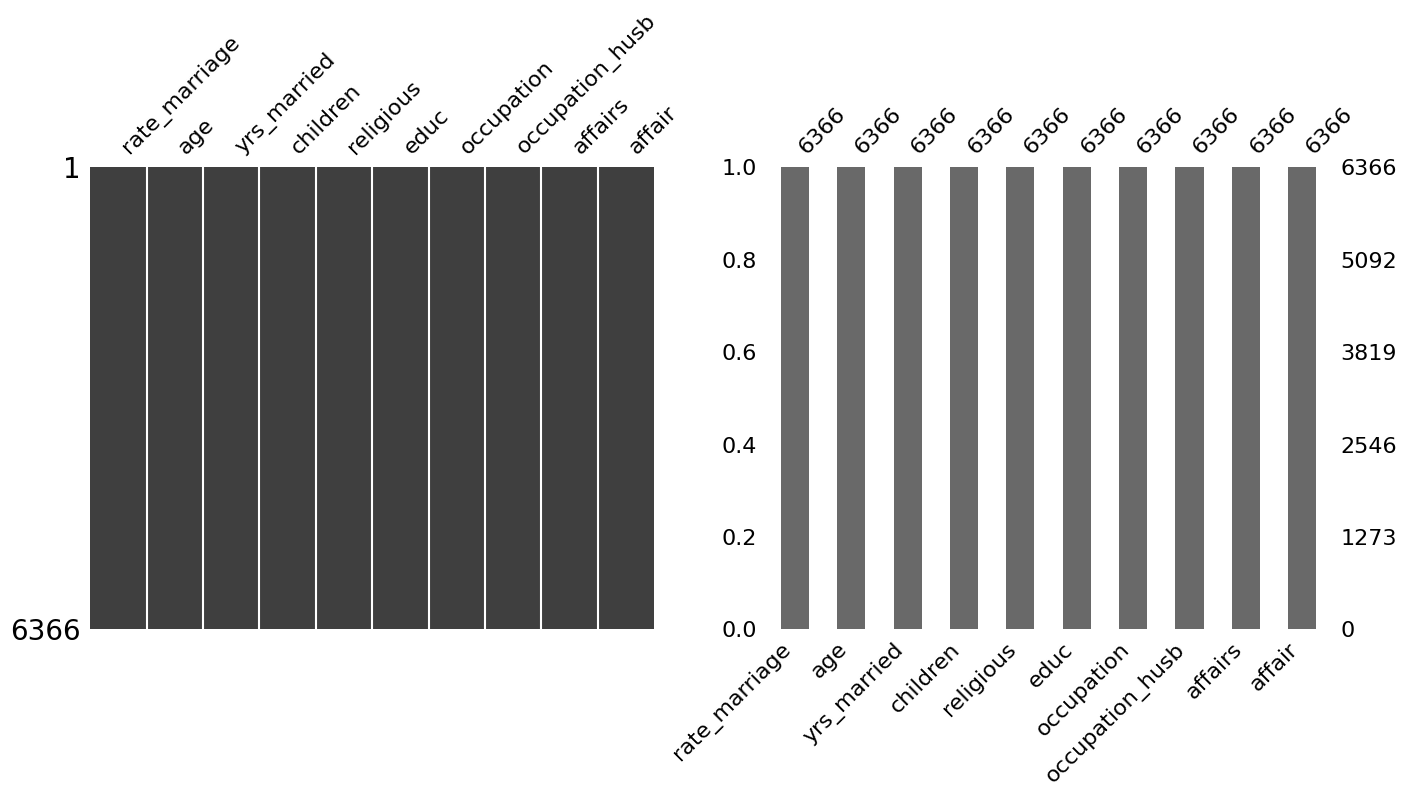

In [67]:
fig, ax = plt.subplots(1,2,figsize=(16,6))
sms.matrix(df, ax=ax[0])
sms.bar(df,ax=ax[1])

In [68]:
df.isna().sum().sum()

np.int64(0)

podemos estar tranquilos de que no hay nulos, incluso nulos ocultos ya que en el analisis rapido los valores minimos y maximos estaban acorde a lo que representan

# EDA UNIVARIADO Y OUTLIERS

Lo primero que hare sera graficar las distribuciones y diagramas de caja para observar la forma y los outliers

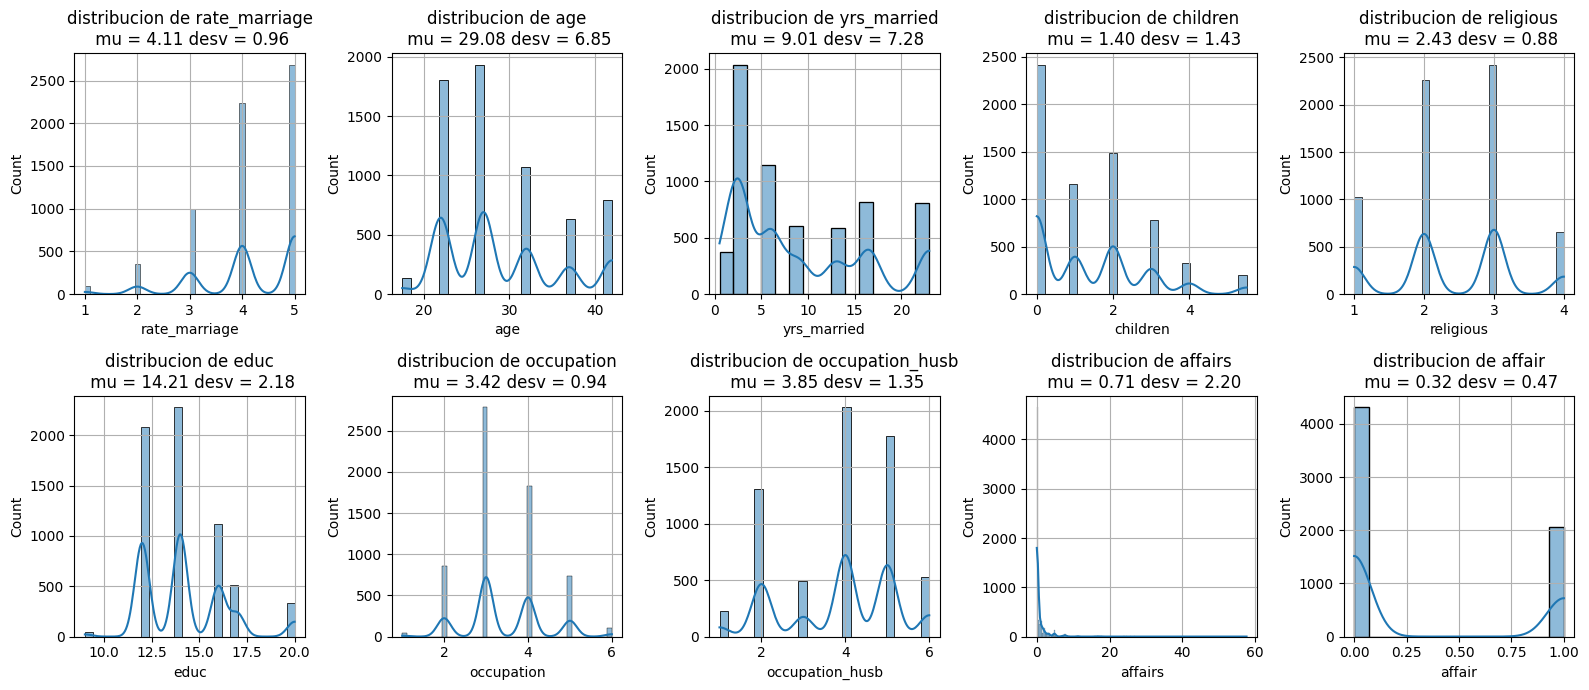

In [69]:
fig, ax = plt.subplots(2,5,figsize = (16,7))
for ax,column in zip(ax.flat,df.columns.to_list()):
    sns.histplot(df[column],ax=ax,kde=True)
    ax.set_title(f'distribucion de {column}\n mu = {df[column].mean():.2f} desv = {df[column].std():.2f}')
    ax.grid(True)


plt.tight_layout()
plt.show()

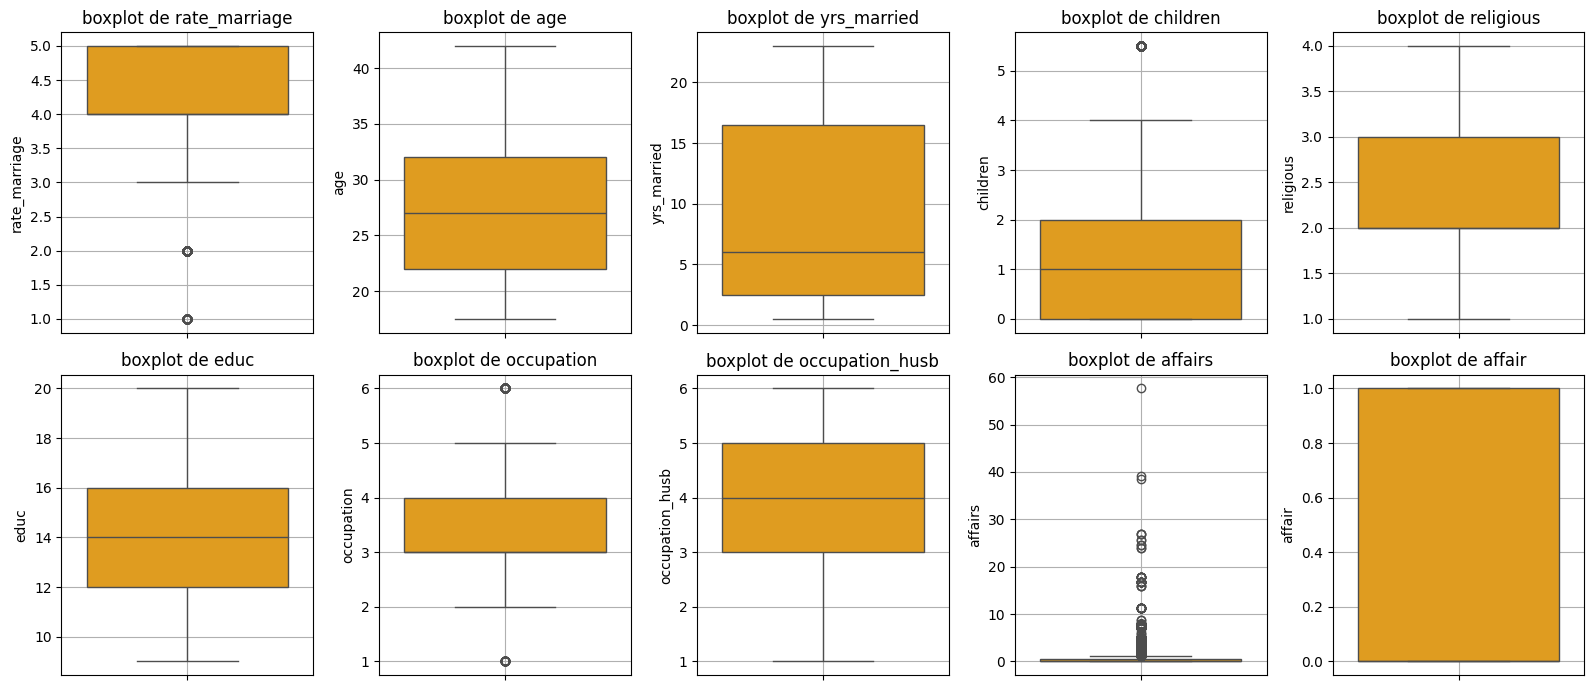

In [70]:
fig, ax = plt.subplots(2,5,figsize = (16,7))
for ax,column in zip(ax.flat,df.columns.to_list()):
    sns.boxplot(df[column],ax=ax,color='orange')
    ax.set_title(f'boxplot de {column}')
    ax.grid(True)
    
plt.tight_layout()
plt.show()

aqui podemos observar varias cosas, me equivoque en pensar que todas eran continuas, podemos ver que affairs esta supersesgada sin embargo la variable objetivo no esta tan sesgada entonces podemos olvidarnos de usar un metodo agresivo de balanceo

revisare mas a fondo la variable objetivo 

<Axes: title={'center': 'no infiel = 0.678   infiel = 0.322'}, xlabel='affair', ylabel='count'>

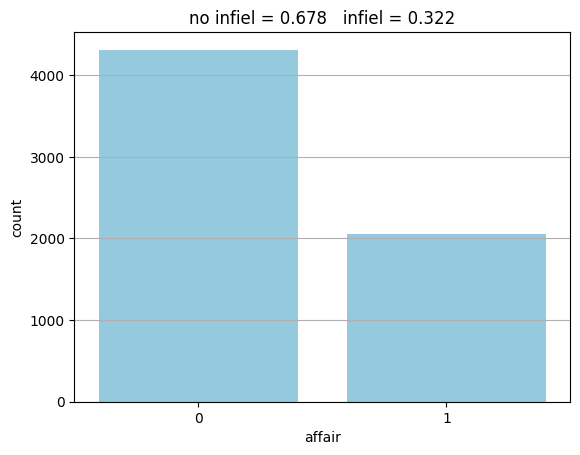

In [71]:
plt.grid(True)
plt.title(f'no infiel = {round(df['affair'].value_counts(normalize=True)[0],3)}   infiel = {round(df['affair'].value_counts(normalize=True)[1],3)}')
sns.countplot(x=df['affair'],color='skyblue')


In [72]:
df['affair'].value_counts()

affair
0    4313
1    2053
Name: count, dtype: int64

ya viendolo asi probablemente ajustare el modelo para que le de mas peso a la variable minoritaria o ajustare el umbral

# ANALISIS BIVARIADO

empecemos con lo clasico: relaciones lineales y multicolinearidad

<Axes: >

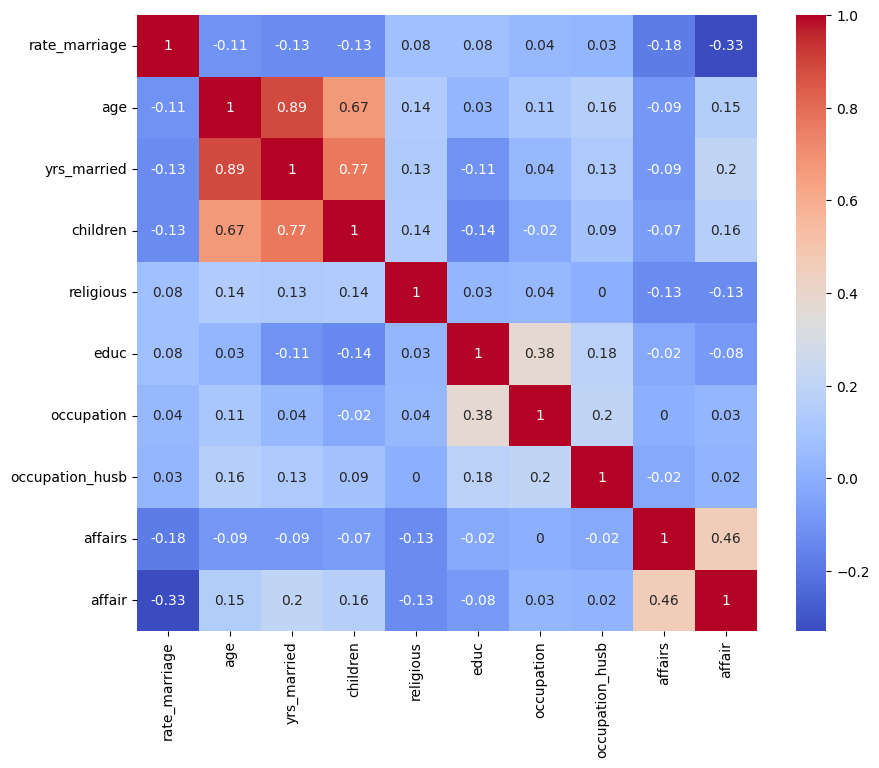

In [73]:
plt.figure(figsize=(10,8))
sns.heatmap(round(df.corr(),2),annot=True,cmap='coolwarm')

que edad tienen mas infieles?

In [74]:
infieles_edad=df.groupby('age')['affair'].agg(['sum','count','mean']).rename(columns={'sum': 'total de infieles', 'count': 'sujetos totales', 'mean': 'tasa de infidelidad'})
infieles_edad

,total de infieles,sujetos totales,tasa de infidelidad
age,,,
17.5,13,139,0.093525
22.0,406,1800,0.225556
27.0,633,1931,0.327809
32.0,425,1069,0.397568
37.0,270,634,0.425868
42.0,306,793,0.385876


<Axes: xlabel='tasa de infidelidad', ylabel='age'>

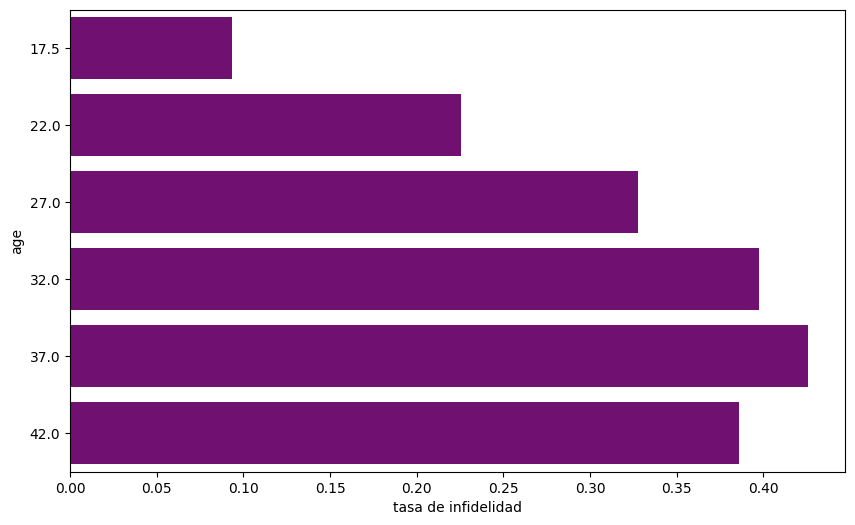

In [75]:
plt.figure(figsize=(10,6))
sns.barplot(x=infieles_edad['tasa de infidelidad'],y=infieles_edad.index,orient='h',color='purple')

existe una relacion estadisticamente significativa de la edad o es puro ruido?

el p valor nos da un valor significativo, eso quiere decir que si existe una relacion entre grupos de edad pero veamos con cramers si el effecto es grande

In [76]:
def crammers(tabla_contingencia):
    chi2,p, dof, excepted  = stats.chi2_contingency(tabla_contingencia)
    n=tabla_contingencia.sum().sum()
    r,k = tabla_contingencia.shape
    v = np.sqrt((chi2/n)/(min(r-1,k-1)))
    return v,chi2,p



hagamos esto con cada variable

In [77]:
cat_col = [x for x in df.columns.to_list() if x not in ['affair','affairs']]
resultados = []
for col in df[cat_col].columns.to_list():
    con_table = pd.crosstab(df[col],df['affair'])
    v,chi2,p=crammers(con_table)
    resultados.append({'variable':col,'effect':v, 'p-value':p})
    

pd.DataFrame(resultados).sort_values(by='effect',ascending=False)

,variable,effect,p-value
0,rate_marriage,0.336033,2.904533e-154
2,yrs_married,0.247341,5.159413e-81
3,children,0.195887,9.303020e-51
1,age,0.170095,6.840950e-38
4,religious,0.133542,1.909881e-24
6,occupation,0.110515,2.477892e-15
5,educ,0.097703,8.428184e-12
7,occupation_husb,0.053801,2.456428e-03


ya con esto encontramos que variables tienen mas efecto o mas efecto con un p valor significativo en cada una

veamos algo interesante, enfoquemosno en yrs_married

In [78]:
tabla = df.groupby('yrs_married')['affair'].agg(['sum','count','mean']).rename(columns={'sum': 'total de infieles','count':'muestra','mean':'tasa de infieles'})
tabla.sort_values(by='total de infieles',ascending=False)

,total de infieles,muestra,tasa de infieles
yrs_married,,,
2.5,439,2034,0.215831
6.0,387,1141,0.339176
16.5,369,818,0.451100
23.0,345,811,0.425401
9.0,254,602,0.421927
13.0,243,590,0.411864
0.5,16,370,0.043243


como vimos antes por el cramers tiene efecto bajo-medio y confirmamos que no es casualidad pero en algunos grupos vemos que no es la misma muestra

<Axes: xlabel='tasa de infieles', ylabel='yrs_married'>

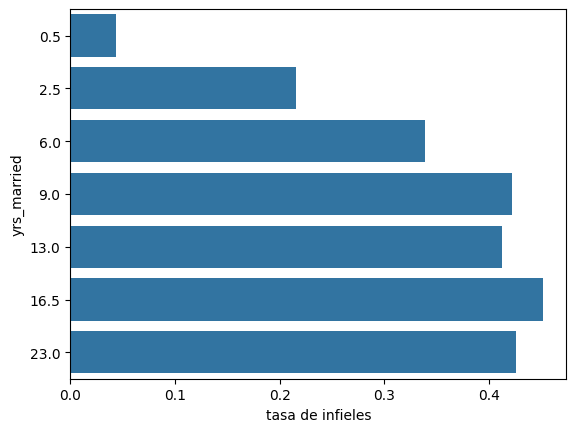

In [79]:
sns.barplot(x=tabla['tasa de infieles'],y=tabla.index,orient='h')

tener hijos podria detener la infidelidad?

In [80]:
tabla = df.groupby('children')['affair'].agg(['sum','count','mean']).rename(columns={'sum': 'total de infieles','count':'muestra','mean':'tasa de infieles'})
tabla.sort_values(by='tasa de infieles')

,total de infieles,muestra,tasa de infieles
children,,,
0.0,502,2414,0.207954
1.0,412,1159,0.355479
5.5,79,203,0.389163
4.0,131,328,0.399390
2.0,608,1481,0.410533
3.0,321,781,0.411012


bueno podemos ver que a tener hijos aumenta la probabilidad de infidelidad y es por el tiempo, esa hipotesis la confirmaremos en la siguiente celda

In [81]:
df.groupby('yrs_married')['children'].mean()

yrs_married
0.5     0.048649
2.5     0.297198
6.0     1.036810
9.0     1.649502
13.0    1.916102
16.5    2.814181
23.0    3.281751
Name: children, dtype: float64

quizas tenga algo de relacion, como vimos antes a mas anos de estar juntos las probabilidades aumentan y a mas edad mas probabilidad de hijos pero tambien de infidelidad

ya con esto contruiremos 2 modelos, uno con interpretacion sencilla y otro con potencia y explicacion mediana gracias a shap

# FEATURE ENGENEERING

In [82]:
df['edad_al_casarse'] = df['age']- df['yrs_married']
df['hijos_por_ano'] = df['children']/(df['yrs_married'] + 1) #por si es 0
df['satisfaccion_x_religiosidad'] = df['rate_marriage'] * df['religious']

df

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs,affair,edad_al_casarse,hijos_por_ano,satisfaccion_x_religiosidad
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111,1,23.0,0.300000,9.0
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769,1,14.0,0.214286,3.0
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000,1,19.5,0.000000,4.0
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273,1,20.5,0.228571,12.0
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666,1,18.0,0.100000,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6361,5.0,32.0,13.0,2.0,3.0,17.0,4.0,3.0,0.000000,0,19.0,0.142857,15.0
6362,4.0,32.0,13.0,1.0,1.0,16.0,5.0,5.0,0.000000,0,19.0,0.071429,4.0
6363,5.0,22.0,2.5,0.0,2.0,14.0,3.0,1.0,0.000000,0,19.5,0.000000,10.0
6364,5.0,32.0,6.0,1.0,3.0,14.0,3.0,4.0,0.000000,0,26.0,0.142857,15.0


In [83]:
df.corr(method='spearman')['affair'][['edad_al_casarse','hijos_por_ano','satisfaccion_x_religiosidad']]

edad_al_casarse               -0.161950
hijos_por_ano                  0.119957
satisfaccion_x_religiosidad   -0.271349
Name: affair, dtype: float64

podemos ver que si tienen buena relacion lineal en especial la de religion, quizas mayor peso en la religion quiera dar mejores valores... o no?

# PREPARACION DE LOS MODELOS

In [84]:
X = df.drop(['affairs','affair'],axis=1) 
y = df['affair']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20, random_state=42)

logit = LogisticRegression()
SVM_gauss = SVC()


escalar variables para la SVM

In [85]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

creamos la funcion objetivo para optimizacion de parametros

In [86]:
def objetive_x(trials):
    n_estimators = trials.suggest_int('n_estimators',100,1000)
    learning_rate = trials.suggest_float('learning_rate',0.01,0.5,log = True)
    max_depth = trials.suggest_int('max_depth',1,14)
    gamma = trials.suggest_float('gamma',0.5,5)
    colsample_bytree = trials.suggest_float('colsample_bytree',0.1,1)
    scale_pos_weight = trials.suggest_float('scale_pos_weight', 1.0, 3.0)
    
    modelo = XGBClassifier(n_estimators=n_estimators,learning_rate=learning_rate,max_depth=max_depth,gamma=gamma,colsample_bytree=colsample_bytree,random_state =42,scale_pos_weight=scale_pos_weight)
    score = cross_val_score(estimator=modelo,X=X_train,y=y_train,scoring='f1',cv=5)
    
    return score.mean()

def objetive_svc(trial):
    C = trial.suggest_float('C', 0.01, 10, log=True)
    gamma = trial.suggest_float('gamma', 0.001, 1, log=True)
    modelo = SVC(kernel='rbf', C=C, gamma=gamma, class_weight='balanced', random_state=42)
    score = cross_val_score(modelo, X_train_scaled, y_train, scoring='f1', cv=5)
    return score.mean()

def objective_logit(trial):
    C = trial.suggest_float('C', 0.001, 100, log=True)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'])
    weight_1 = trial.suggest_float('weight_1', 1.0, 3.0)
    
    modelo = LogisticRegression(C=C, solver=solver, class_weight={0: 1, 1: weight_1}, max_iter=2000)
    score = cross_val_score(modelo, X_train, y_train, scoring='f1', cv=5)
    return score.mean()
    

ENCONTRAR LOS MEJORES HIPERPARAMETROS PARA EL XGBOOST

In [87]:
study=optuna.create_study(direction='maximize')

[I 2026-07-07 15:23:35,874] A new study created in memory with name: no-name-e77f2026-0e38-48e1-8b14-cad40ddb7113


In [88]:
study.optimize(objetive_x,n_trials=200)

[I 2026-07-07 15:23:36,251] Trial 0 finished with value: 0.5704704973190715 and parameters: {'n_estimators': 419, 'learning_rate': 0.1259999667324526, 'max_depth': 11, 'gamma': 1.5458392042592457, 'colsample_bytree': 0.3035244823747988, 'scale_pos_weight': 1.7253870645796332}. Best is trial 0 with value: 0.5704704973190715.
[I 2026-07-07 15:23:37,077] Trial 1 finished with value: 0.5752357200929621 and parameters: {'n_estimators': 718, 'learning_rate': 0.01606447030484907, 'max_depth': 11, 'gamma': 1.3934316248426022, 'colsample_bytree': 0.3549586979445708, 'scale_pos_weight': 2.4403613127964974}. Best is trial 1 with value: 0.5752357200929621.
[I 2026-07-07 15:23:37,582] Trial 2 finished with value: 0.5755726620724564 and parameters: {'n_estimators': 333, 'learning_rate': 0.012224233903169731, 'max_depth': 9, 'gamma': 3.929373502775694, 'colsample_bytree': 0.9683721270940541, 'scale_pos_weight': 2.971346605058477}. Best is trial 2 with value: 0.5755726620724564.
[I 2026-07-07 15:23:37

In [89]:
optuna.visualization.plot_optimization_history(study=study)

ENCONTRAR LOS MEJORES HIPERPARAMETROS PARA LA SVM

In [90]:
study2 = optuna.create_study(direction='maximize')

[I 2026-07-07 15:24:24,690] A new study created in memory with name: no-name-d6b73233-afc8-47b8-a74c-88e261c567bb


In [91]:
study2.optimize(objetive_svc,n_trials=250)

[I 2026-07-07 15:24:26,502] Trial 0 finished with value: 0.5844638340695025 and parameters: {'C': 0.2199457232477196, 'gamma': 0.021958507971785512}. Best is trial 0 with value: 0.5844638340695025.
[I 2026-07-07 15:24:28,651] Trial 1 finished with value: 0.5750124671082855 and parameters: {'C': 0.035136743873163116, 'gamma': 0.2593065811043337}. Best is trial 0 with value: 0.5844638340695025.
[I 2026-07-07 15:24:30,531] Trial 2 finished with value: 0.579565904279044 and parameters: {'C': 0.04925217988039539, 'gamma': 0.03717757003853993}. Best is trial 0 with value: 0.5844638340695025.
[I 2026-07-07 15:24:32,459] Trial 3 finished with value: 0.5284328812673971 and parameters: {'C': 2.315031024757323, 'gamma': 0.2852347676759436}. Best is trial 0 with value: 0.5844638340695025.
[I 2026-07-07 15:24:34,341] Trial 4 finished with value: 0.5668302830082501 and parameters: {'C': 0.40111713297545326, 'gamma': 0.2963203588869}. Best is trial 0 with value: 0.5844638340695025.
[I 2026-07-07 15:2

In [92]:
optuna.visualization.plot_optimization_history(study2)

poodemos ver que de alguna forma se optimizo mejor

enhcontrar los mejores hiperparametros para logit

In [93]:
study3 = optuna.create_study(direction='maximize')
study3.optimize(objective_logit,n_trials=250)

[I 2026-07-07 15:31:35,936] A new study created in memory with name: no-name-b91732ec-6d0d-4e97-9a2c-e7c60f4c3d89
[I 2026-07-07 15:31:36,366] Trial 0 finished with value: 0.5732438154112318 and parameters: {'C': 0.001355772081275521, 'solver': 'sag', 'weight_1': 2.6581532736171702}. Best is trial 0 with value: 0.5732438154112318.
[I 2026-07-07 15:31:36,411] Trial 1 finished with value: 0.5083694701086496 and parameters: {'C': 0.0012203435894501502, 'solver': 'newton-cg', 'weight_1': 1.4079032832864888}. Best is trial 0 with value: 0.5732438154112318.
[I 2026-07-07 15:31:36,452] Trial 2 finished with value: 0.5790644857242889 and parameters: {'C': 0.002482494698686326, 'solver': 'newton-cg', 'weight_1': 2.3095205381880612}. Best is trial 2 with value: 0.5790644857242889.
[I 2026-07-07 15:31:38,856] Trial 3 finished with value: 0.5280296494546856 and parameters: {'C': 0.19664490817506017, 'solver': 'saga', 'weight_1': 1.5043548753006115}. Best is trial 2 with value: 0.5790644857242889.
[

In [94]:
optuna.visualization.plot_optimization_history(study3)

# ENTRENAMIENTO DE LOS MODELOS

In [95]:
model = XGBClassifier(**study.best_params)
model_svm = SVC(**study2.best_params,class_weight='balanced',kernel='rbf')
params = study3.best_params.copy()
weight_1 = params.pop('weight_1')  

logit = LogisticRegression(
    **params,
    class_weight={0: 1, 1: weight_1},
    max_iter=100000
)

In [96]:
model.fit(X_train,y_train)
model_svm.fit(X_train_scaled,y_train)
logit.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",50.9793199922317
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{0: 1, 1: 2.567601225434538}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a 

Text(0.5, 1.0, 'variales que ayudaron a purificar el modelo')

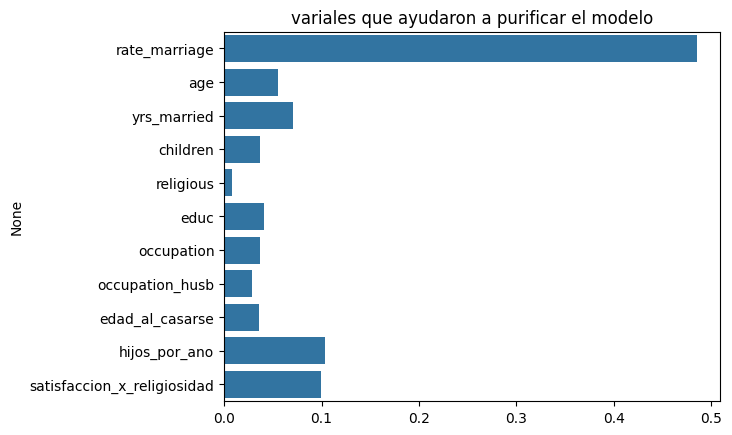

In [97]:
sns.barplot(x=model.feature_importances_,y=X_train.columns)
plt.title('variales que ayudaron a purificar el modelo')

In [98]:
y_pred = model.predict(X_test)
y_pred_svm = model_svm.predict(X_test_scaled)
y_pred_logit = logit.predict(X_test)
y_preds = [y_pred,y_pred_logit,y_pred_svm]
models = ['xgboost','log-reg','svm']

for name,pred in zip(models,y_preds):
    print(f'resultados de {name}: \n {confusion_matrix(y_test,pred)}')
    print(f'resultados del reporte \n {classification_report(y_test,pred)}')


resultados de xgboost: 
 [[494 355]
 [ 90 335]]
resultados del reporte 
               precision    recall  f1-score   support

           0       0.85      0.58      0.69       849
           1       0.49      0.79      0.60       425

    accuracy                           0.65      1274
   macro avg       0.67      0.69      0.65      1274
weighted avg       0.73      0.65      0.66      1274

resultados de log-reg: 
 [[506 343]
 [ 95 330]]
resultados del reporte 
               precision    recall  f1-score   support

           0       0.84      0.60      0.70       849
           1       0.49      0.78      0.60       425

    accuracy                           0.66      1274
   macro avg       0.67      0.69      0.65      1274
weighted avg       0.72      0.66      0.67      1274

resultados de svm: 
 [[548 301]
 [114 311]]
resultados del reporte 
               precision    recall  f1-score   support

           0       0.83      0.65      0.73       849
           1       0.5

In [99]:
model_dummy = DummyClassifier(strategy='stratified').fit(X_train,y_train)
predict_dummy = model_dummy.predict(X_test)
print(classification_report(y_test, predict_dummy))
print(confusion_matrix(y_test, predict_dummy))

              precision    recall  f1-score   support

           0       0.65      0.67      0.66       849
           1       0.29      0.27      0.28       425

    accuracy                           0.54      1274
   macro avg       0.47      0.47      0.47      1274
weighted avg       0.53      0.54      0.53      1274

[[569 280]
 [311 114]]


In [100]:
reultados_f1 = []
resultados_acurracy = []
resultados_recall = []
predicts = [y_pred_logit,y_pred_svm,y_pred,predict_dummy]
for i in predicts:
    reultados_f1.append(f1_score(y_test,i))
    resultados_recall.append(recall_score(y_test,i))
    resultados_acurracy.append(accuracy_score(y_test,i))
    
models.append('dummy')

In [101]:
df_resultados = pd.DataFrame({
    'model' :['xgboost','svm','log-reg','dummy'],
    'Accuracy': resultados_acurracy,
    'Precision/Recall': resultados_recall,
    'F1-Score': reultados_f1
})

# Mostrar la tabla ordenada de mejor a peor según F1-Score
print(df_resultados.sort_values(by='F1-Score', ascending=False))

     model  Accuracy  Precision/Recall  F1-Score
0  xgboost  0.656201          0.776471  0.601093
2  log-reg  0.650706          0.788235  0.600897
1      svm  0.674254          0.731765  0.599807
3    dummy  0.536107          0.268235  0.278388


aqui podemos ver que practicamente los modelos quedaron muy igualado, el techo no lo pone el modelo, el techo es por los datos y la complejidad del reto

In [102]:
df_long = pd.melt(df_resultados, id_vars=['model'], var_name='Métrica', value_name='Valor')


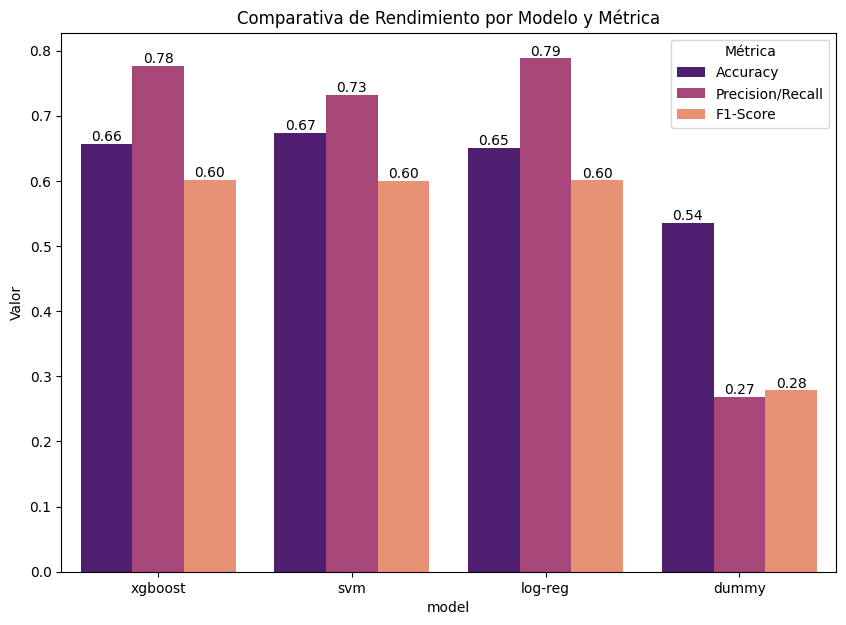

In [103]:
plt.figure(figsize=(10,7))
ax = sns.barplot(data=df_long, x='model', y='Valor', hue='Métrica', palette='magma')
plt.title('Comparativa de Rendimiento por Modelo y Métrica')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

In [104]:
f1_dummy = df_resultados['F1-Score'].iloc[-1]

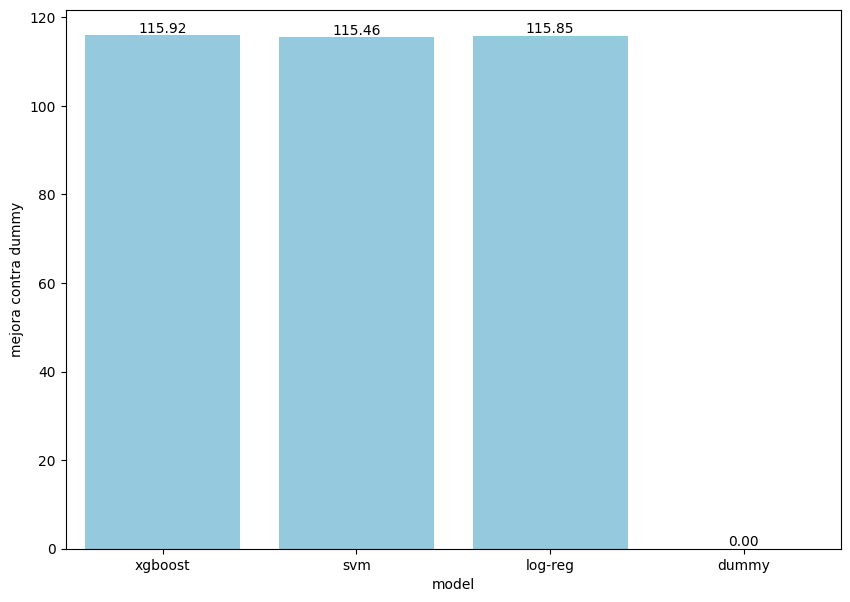

In [105]:
plt.figure(figsize=(10,7))
df_resultados['mejora contra dummy']=((df_resultados['F1-Score']-f1_dummy)/f1_dummy) * 100
ax = sns.barplot(data=df_resultados,x='model',y='mejora contra dummy',color='skyblue')

for containers in ax.containers:
    ax.bar_label(containers,fmt='%.2f')

# SHAP

usaremos la libreria shap para interpretar nuestro xgboost

In [106]:
explainer = shap.TreeExplainer(model=model,model_output='probability',data=X_train)
shap_values = explainer(X_test)

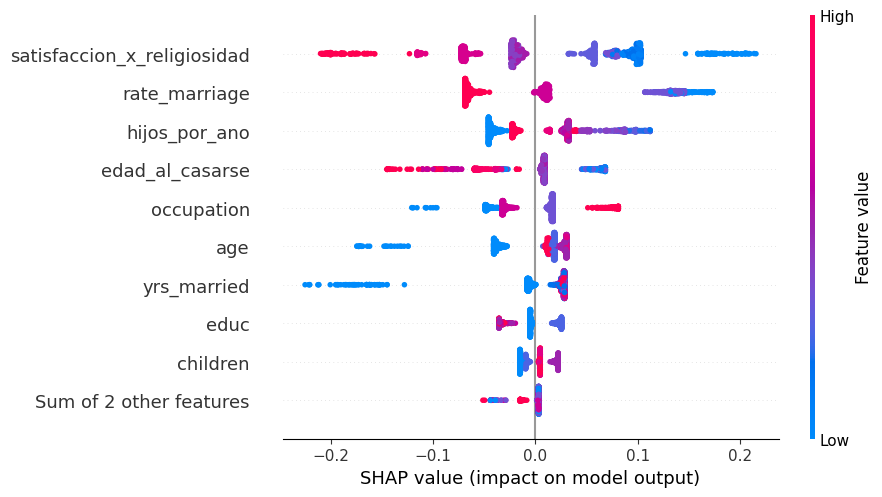

In [107]:
shap.plots.beeswarm(shap_values)

caso donde es probable que sea infiel

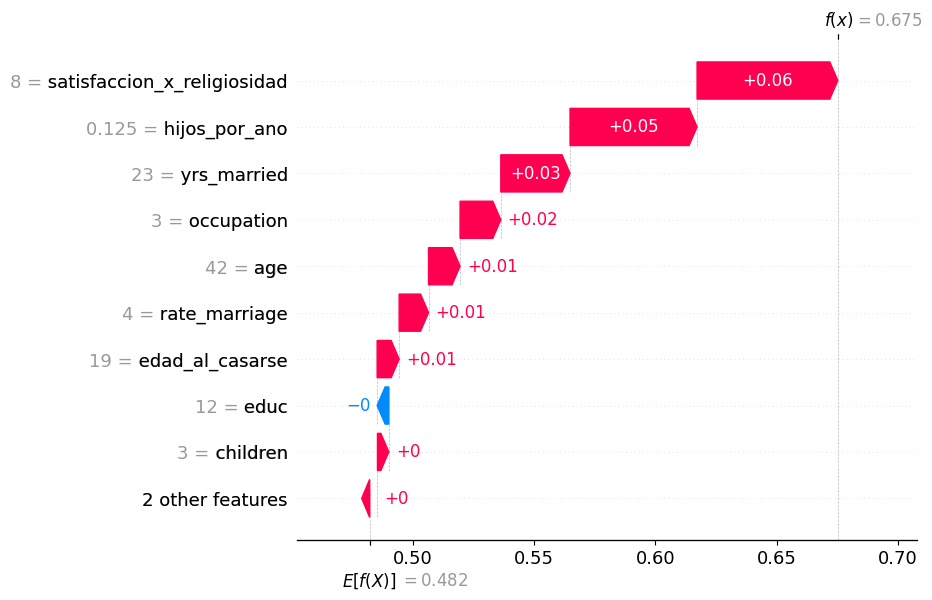

In [108]:
shap.plots.waterfall(shap_values[4])

caso donde es probable que no sea infiel

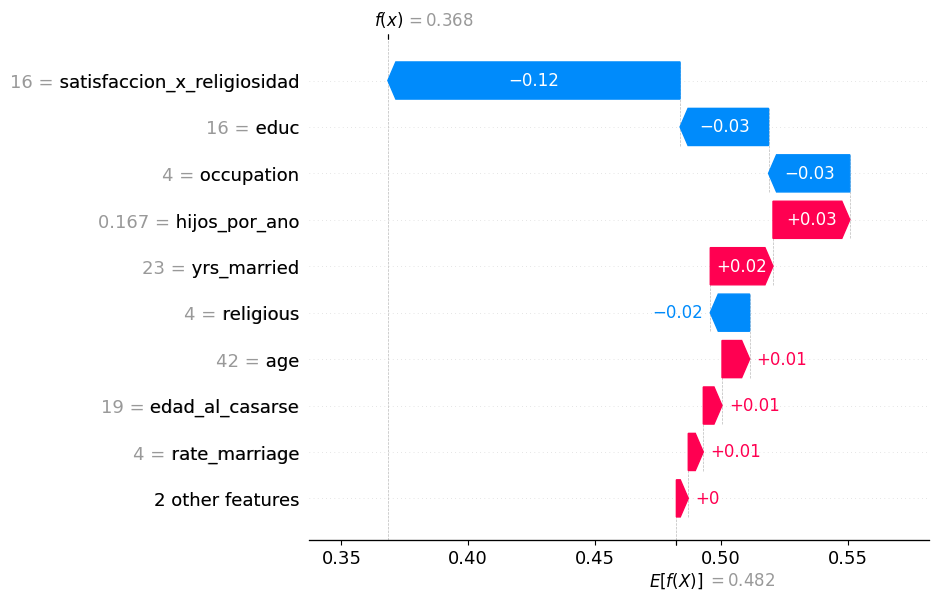

In [109]:
shap.plots.waterfall(shap_values[0])

podemos ver que la variable mas fuerte para que no sea infiel es la satisfaccion y religiosidad y la mas fuerte son los anos 

guardamos el mejor modelo

In [110]:
dump(model,'model.pkl')

['model.pkl']